# Using MLflow to observe the agent

MLflow observability into LangGraph workflows. 

We can Trace and log each step of workflow like LLM invocation , tool usage etc

In [2]:
#!pip install mlflow

import mlflow
import os
from typing import Dict
from tavily import TavilyClient
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display

/opt/anaconda3/envs/udemyllms/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Run mlflow server on terminal 
# mlflow server --host 127.0.0.1 --port 5000 


tracking_uri = "http://127.0.0.1:5000"
mlflow.set_tracking_uri(tracking_uri)

In [7]:
experiment = mlflow.set_experiment("agentic_ai")

2026/09/22 12:38:40 INFO mlflow.tracking.fluent: Experiment with name 'agentic_ai' does not exist. Creating a new experiment.


In [11]:
@mlflow.trace
def add(a, b):
    return a + b

Trace(trace_id=tr-f7fe2107773f38eab277a6c4dda88eca)

In [13]:
add(1, 2)

3

Trace(trace_id=tr-3b259acb712f0fce1ab0dd5e94d98976)

In [5]:
@tool
def web_search(question:str)->Dict:
    """
    Return top search results for a given search query
    """
    tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    response = tavily_client.search(question)
    return response

In [6]:
class State(MessagesState):
    question: str
    answer: str

In [3]:
from dotenv import load_dotenv
load_dotenv("/Users/oasis/Udacity AI Masters/Agentic/Code/.env")
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
)

In [7]:
llm_with_tools = llm.bind_tools([web_search])

def entry_point(state: State):
    question = state["question"]
    system_message = SystemMessage("You conduct web search to respond to user's questions")
    human_message = HumanMessage(question)
    messages = [system_message, human_message]
    return {"messages": messages}


def agent(state: State):
    messages = state["messages"]
    ai_message = llm_with_tools.invoke(messages)
    return {"messages": ai_message, "answer": ai_message.content}


def router(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"

    return END


workflow = StateGraph(State)
workflow.add_node("entry_point", entry_point)
workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode([web_search]))

workflow.add_edge(START, "entry_point")
workflow.add_edge("entry_point", "agent")
workflow.add_conditional_edges(
    source="agent", 
    path=router, 
    path_map=["tools", END]
)
workflow.add_edge("tools", "agent")

In [21]:
memory = MemorySaver()
graph = workflow.compile(
    interrupt_before=["tools"], 
    checkpointer=memory
)

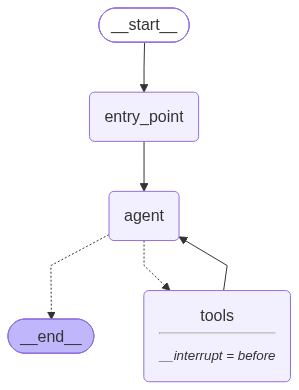

In [22]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [23]:
mlflow.langchain.autolog()

In [24]:
input_question = {"question": "what's the capital of Brazil?"}
config = {"configurable": {"thread_id": 1}}

In [25]:
for event in graph.stream(input=input_question, config=config, stream_mode="values"):
    if not event['messages']:
        continue
    event['messages'][-1].pretty_print()

2026/09/22 13:33:04 WARNING mlflow.tracing.fluent: Found non-string values in metadata. Non-string values in metadata will automatically be stringified when the trace is logged. Non-string items: {'mlflow.trace.session': 1}
2026/09/22 13:33:04 WARNING mlflow.tracing.fluent: Found non-string values in metadata. Non-string values in metadata will automatically be stringified when the trace is logged. Non-string items: {'mlflow.trace.session': 1}
2026/09/22 13:33:04 WARNING mlflow.tracing.fluent: Found non-string values in metadata. Non-string values in metadata will automatically be stringified when the trace is logged. Non-string items: {'mlflow.trace.session': 1}


================================ Human Message =================================

what's the capital of Brazil?


2026/09/22 13:33:06 WARNING mlflow.tracing.fluent: Found non-string values in metadata. Non-string values in metadata will automatically be stringified when the trace is logged. Non-string items: {'mlflow.trace.session': 1}
Error in MlflowLangchainTracer.on_interrupt callback: AttributeError("'MlflowLangchainTracer' object has no attribute 'on_interrupt'")


================================== Ai Message ==================================
Tool Calls:
  web_search (call_bvrrDdC5YaE1SARD62wKVq9T)
 Call ID: call_bvrrDdC5YaE1SARD62wKVq9T
  Args:
    question: capital of Brazil


In [26]:
state = graph.get_state(config=config)

Trace(trace_id=tr-52ea9c4a08599505750e59d61f0618c6)

In [27]:
state.next

('tools',)

In [28]:
for event in graph.stream(input=None, config=config, stream_mode="values"):
    if not event['messages']:
        continue
    event['messages'][-1].pretty_print()

Error in MlflowLangchainTracer.on_resume callback: AttributeError("'MlflowLangchainTracer' object has no attribute 'on_resume'")


================================== Ai Message ==================================
Tool Calls:
  web_search (call_bvrrDdC5YaE1SARD62wKVq9T)
 Call ID: call_bvrrDdC5YaE1SARD62wKVq9T
  Args:
    question: capital of Brazil
================================= Tool Message =================================
Name: web_search

{"query": "capital of Brazil", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.gov.br/g20/en/about-the-g20/host-cities/brasilia-df", "title": "Brasília - DF", "content": "Brasília is the capital of Brazil and the seat of government of the Federal District and the federal government. It is located in the Center-West region of the country. Those born in Brasília are brasilienses (Brasilians). The capital of Brazil is an architectural masterpiece designed by Oscar Niemeyer and Lúcio Costa. It was inaugurated on April 21, 1960, and its landscape is marked by iconic monuments such as the Metropolitan Cathedral and the National Congress.

In [29]:
state = graph.get_state(config=config)

Trace(trace_id=tr-4756f563e706029deb8f1ca473dfb5fc)

# Adding Human in the loop



In [8]:
workflow = StateGraph(State)
workflow.add_node("entry_point", entry_point)
workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode([web_search]))

workflow.add_edge(START, "entry_point")
workflow.add_edge("entry_point", "agent")
workflow.add_conditional_edges(
    source="agent", 
    path=router, 
    path_map=["tools", END]
)
workflow.add_edge("tools", "agent")

In [9]:
memory = MemorySaver()
graph = workflow.compile(
    interrupt_before=["tools"], 
    checkpointer=memory
)

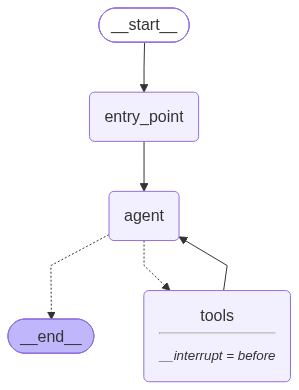

In [10]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [11]:
input_question = {"question": "what's the capital of Brazil?"}
config = {"configurable": {"thread_id": 1}}

In [12]:
for event in graph.stream(input=input_question, config=config, stream_mode="values"):
    if not event['messages']:
        continue
    event['messages'][-1].pretty_print()

================================ Human Message =================================

what's the capital of Brazil?
================================== Ai Message ==================================
Tool Calls:
  web_search (call_Ry5NEgwvMNKAyZ6VHcH5k9GJ)
 Call ID: call_Ry5NEgwvMNKAyZ6VHcH5k9GJ
  Args:
    question: capital of Brazil


In [13]:
state = graph.get_state(config=config)

In [14]:
state

StateSnapshot(values={'messages': [SystemMessage(content="You conduct web search to respond to user's questions", additional_kwargs={}, response_metadata={}, id='2fb834a2-2189-4b82-aa8e-85c4eeadc3c2'), HumanMessage(content="what's the capital of Brazil?", additional_kwargs={}, response_metadata={}, id='028b163d-15ff-4120-90a3-330739e9f351'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 64, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2e30314e0f', 'id': 'chatcmpl-EQsaLX0pwA7ZPIIFjhw9xrWOZ1kRB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0c8c9-c00a-7462

In [15]:
state.next

('tools',)

In [16]:
# Proceeding further

for event in graph.stream(input=None, config=config, stream_mode="values"):
    if not event['messages']:
        continue
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  web_search (call_Ry5NEgwvMNKAyZ6VHcH5k9GJ)
 Call ID: call_Ry5NEgwvMNKAyZ6VHcH5k9GJ
  Args:
    question: capital of Brazil
================================= Tool Message =================================
Name: web_search

{"query": "capital of Brazil", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.gov.br/g20/en/about-the-g20/host-cities/brasilia-df", "title": "Brasília - DF", "content": "Brasília is the capital of Brazil and the seat of government of the Federal District and the federal government. It is located in the Center-West region of the country. Those born in Brasília are brasilienses (Brasilians). The capital of Brazil is an architectural masterpiece designed by Oscar Niemeyer and Lúcio Costa. It was inaugurated on April 21, 1960, and its landscape is marked by iconic monuments such as the Metropolitan Cathedral and the National Congress.

## Adding **Human Approval**

In [18]:
from langgraph.graph.state import CompiledStateGraph


def human_in_the_loop_run(graph:CompiledStateGraph, question:str, thread_id:int):
    input_question = {"question": question}
    config = {"configurable": {"thread_id": thread_id}}
    for event in graph.stream(input=input_question, config=config, stream_mode="values"):
        if not event['messages']:
            continue
        event['messages'][-1].pretty_print()
    
    human_input = input("Do you approve the tool calling? (YES or NO): ")
    if human_input.lower() == "yes":
        for event in graph.stream(input=None, config=config, stream_mode="values"):
            if not event['messages']:
                continue
            event['messages'][-1].pretty_print()
    
    else:
        SystemMessage("Workflow aborted by a human").pretty_print()

In [19]:
human_in_the_loop_run(
    graph=graph,
    question="what's the capital of Brazil?",
    thread_id=4,
)

================================ Human Message =================================

what's the capital of Brazil?
================================== Ai Message ==================================
Tool Calls:
  web_search (call_1h98gtFVFOSCwaoLIdMvcs57)
 Call ID: call_1h98gtFVFOSCwaoLIdMvcs57
  Args:
    question: capital of Brazil
================================== Ai Message ==================================
Tool Calls:
  web_search (call_1h98gtFVFOSCwaoLIdMvcs57)
 Call ID: call_1h98gtFVFOSCwaoLIdMvcs57
  Args:
    question: capital of Brazil
================================= Tool Message =================================
Name: web_search

{"query": "capital of Brazil", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.gov.br/g20/en/about-the-g20/host-cities/brasilia-df", "title": "Brasília - DF - Portal Gov.br", "content": "Brasília is the capital of Brazil and the seat of government of the Federal District and the federal government. It is loc

# Adding Human Revision

### When asked say "NO" then modify the user query

In [29]:
memory = MemorySaver()
graph = workflow.compile(
    interrupt_before=["agent"], 
    checkpointer=memory
)

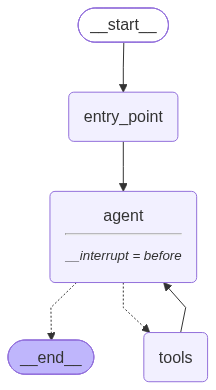

In [30]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [31]:
def human_in_the_loop_run(graph:CompiledStateGraph, question:str, thread_id:int):
    input_question = {"question": question}
    config = {"configurable": {"thread_id": thread_id}}
    for event in graph.stream(input=input_question, config=config, stream_mode="values"):
        if not event['messages']:
            continue
        event['messages'][-1].pretty_print()

    human_input = input("Do you want to proceed with this question? (YES or NO): ")
    
    if human_input.lower() == "no":
        human_input = input("So what should be the question? ")
        human_message = HumanMessage(content=human_input)
        system_message = SystemMessage("Workflow edited by a human")
        system_message.pretty_print()
        graph.update_state(
            config=config,
            values={
                "messages": [
                    system_message,
                    human_message,
                ]
            },
        )

        for event in graph.stream(input=None, config=config, stream_mode="values"):
            if not event['messages']:
                continue
            event['messages'][-1].pretty_print()
    
    for event in graph.stream(input=None, config=config, stream_mode="values"):
        if not event['messages']:
            continue
        event['messages'][-1].pretty_print()


In [32]:
human_in_the_loop_run(
    graph=graph,
    question="what's the capital of Brazil?",
    thread_id=5,
)

================================ Human Message =================================

what's the capital of Brazil?
================================ System Message ================================

Workflow edited by a human
================================ Human Message =================================

What is capital of Japan
================================== Ai Message ==================================
Tool Calls:
  web_search (call_WMjvadGMcoYP5KCfyUtojBTj)
 Call ID: call_WMjvadGMcoYP5KCfyUtojBTj
  Args:
    question: What is the capital of Japan?
================================= Tool Message =================================
Name: web_search

{"query": "What is the capital of Japan?", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.britannica.com/question/What-is-the-capital-of-Japan", "title": "What is the capital of Japan?", "content": "Encyclopedia Britannica\nEncyclopedia Britannica\n\n# What is the capital of Japan?\n\nThe capital 